# Frota por habitante: Uberlândia e outras cidades de Minas

A análise 04 olhou a frota de Uberlândia por dentro. Aqui a pergunta é outra: a cidade tem muito carro **para o tamanho dela**? Para responder, cruzei dois dados oficiais:

- Frota por município (Senatran, julho de 2026);
- População do Censo 2022 (IBGE).

Comparei Uberlândia com Belo Horizonte, Contagem, Juiz de Fora e Uberaba.

## Preparando os dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def br(x, dec=0):
    s = f"{x:,.{dec}f}"
    return s.replace(",", "X").replace(".", ",").replace("X", ".")

df = pd.read_csv("dados/frota_cidades.csv")
df["veiculos_por_hab"] = df["frota_total_jul2026"] / df["populacao_2022"]
df["autos_por_hab"] = df["automoveis"] / df["populacao_2022"]
df["motos_por_hab"] = df["motocicletas_motonetas"] / df["populacao_2022"]
df["pct_motos"] = df["motocicletas_motonetas"] / df["frota_total_jul2026"] * 100
df.sort_values("veiculos_por_hab", ascending=False)

,municipio,populacao_2022,frota_total_jul2026,automoveis,motocicletas_motonetas,veiculos_por_hab,autos_por_hab,motos_por_hab,pct_motos
1,Belo Horizonte,2315560,2904961,1840956,354207,1.254539,0.795037,0.152968,12.193176
4,Uberaba,337836,270670,139661,68475,0.801188,0.413399,0.202687,25.298334
0,Uberlândia,713224,565639,284490,141645,0.793073,0.398879,0.198598,25.041590
2,Contagem,621863,397144,223922,74953,0.638636,0.360083,0.120530,18.873003
3,Juiz de Fora,540756,318559,194393,57712,0.589099,0.359484,0.106725,18.116581


## Veículos por habitante

Dividindo a frota pela população, dá para comparar cidades de tamanhos bem diferentes.

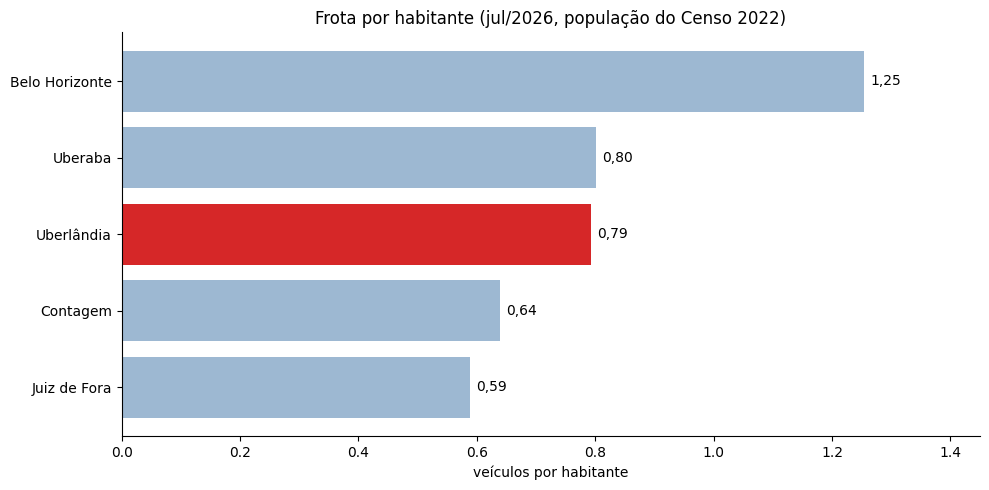

In [2]:
d = df.sort_values("veiculos_por_hab")
cores = ["#d62728" if m == "Uberlândia" else "#9db8d2" for m in d["municipio"]]
fig, ax = plt.subplots()
bars = ax.barh(d["municipio"], d["veiculos_por_hab"], color=cores)
for b, v in zip(bars, d["veiculos_por_hab"]):
    ax.text(v + 0.01, b.get_y() + b.get_height()/2, br(v, 2),
            va="center", fontsize=10)
ax.set_xlabel("veículos por habitante")
ax.set_title("Frota por habitante (jul/2026, população do Censo 2022)")
ax.set_xlim(0, 1.45)
plt.tight_layout()
plt.savefig("grafico_veiculos_por_hab.png", dpi=150)
plt.show()

Uberlândia tem 0,79 veículo por habitante. Fica atrás de Belo Horizonte (1,25) e praticamente empatada com Uberaba (0,80), mas bem à frente de Contagem (0,64) e Juiz de Fora (0,59).

O número de Belo Horizonte acima de 1 não significa que cada morador tenha um carro: a frota municipal inclui veículos de empresas, frotas de órgãos públicos e caminhões registrados na cidade, além de utilitários e reboques.

## Carros e motos

Separando automóveis de motocicletas (somando motocicletas e motonetas), o perfil de cada cidade aparece melhor.

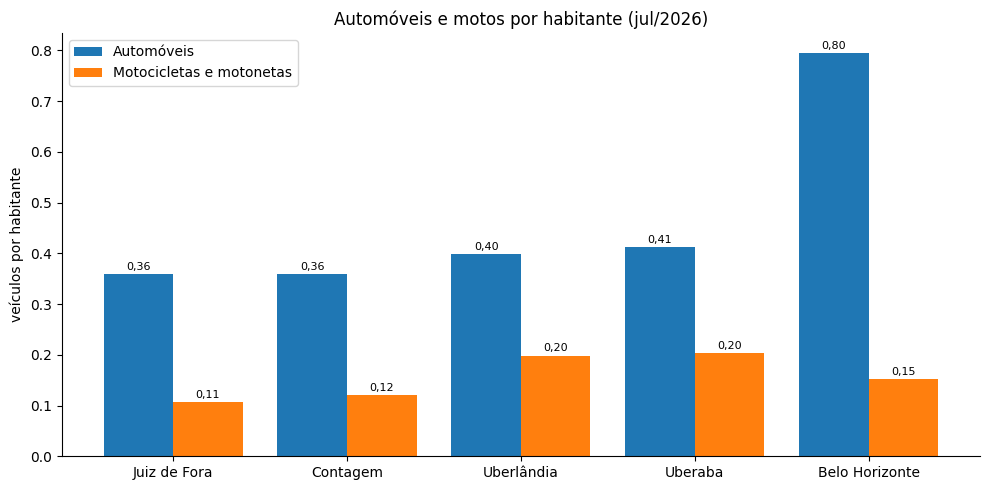

In [3]:
d2 = df.sort_values("autos_por_hab")
x = range(len(d2))
fig, ax = plt.subplots()
b1 = ax.bar([i - 0.2 for i in x], d2["autos_por_hab"], width=0.4, label="Automóveis", color="#1f77b4")
b2 = ax.bar([i + 0.2 for i in x], d2["motos_por_hab"], width=0.4, label="Motocicletas e motonetas", color="#ff7f0e")
ax.set_xticks(list(x))
ax.set_xticklabels(d2["municipio"])
ax.set_ylabel("veículos por habitante")
ax.set_title("Automóveis e motos por habitante (jul/2026)")
ax.legend()
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.008, f"{b.get_height():.2f}".replace(".", ","),
            ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("grafico_autos_motos.png", dpi=150)
plt.show()

## O peso das motos em Uberlândia

Um detalhe que chama atenção: em Uberlândia, motocicletas e motonetas são 25% da frota, a maior fatia entre as cidades da comparação junto com Uberaba. Em Belo Horizonte, só 12%.

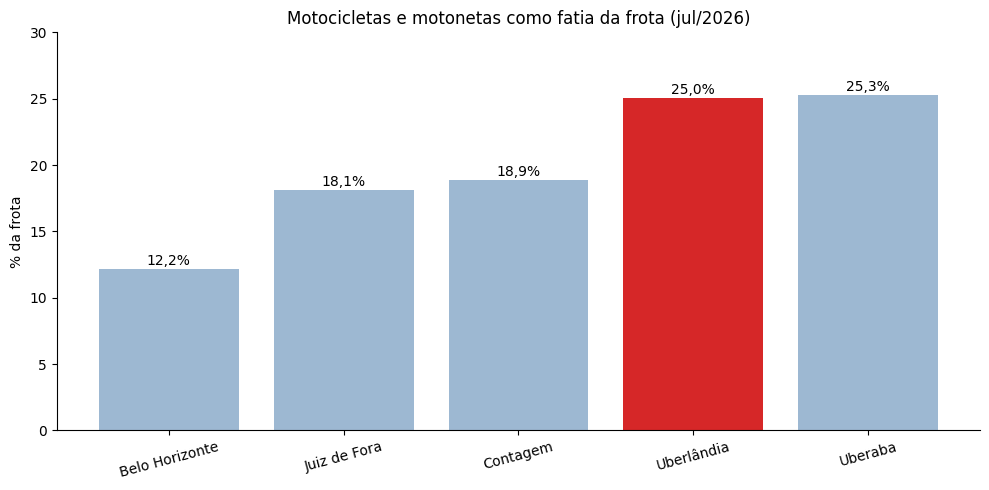

In [4]:
d3 = df.sort_values("pct_motos")
cores = ["#d62728" if m == "Uberlândia" else "#9db8d2" for m in d3["municipio"]]
fig, ax = plt.subplots()
bars = ax.bar(d3["municipio"], d3["pct_motos"], color=cores)
for b, v in zip(bars, d3["pct_motos"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.3, br(v, 1) + "%", ha="center", fontsize=10)
ax.set_ylabel("% da frota")
ax.set_title("Motocicletas e motonetas como fatia da frota (jul/2026)")
ax.set_ylim(0, 30)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("grafico_pct_motos.png", dpi=150)
plt.show()

## O que dá para concluir

- Uberlândia tem 0,79 veículo por habitante: cerca de 35% mais que Juiz de Fora (0,59) e 24% mais que Contagem (0,64), mas bem menos que Belo Horizonte (1,25).
- A motorização da cidade passa muito pelas motos: 1 em cada 4 veículos emplacados é motocicleta ou motoneta.
- Belo Horizonte lidera com folga, mas boa parte vem de frotas de empresas e órgãos públicos registradas na capital.

## Fontes

- Frota: Senatran, "Frota por município e tipo", julho/2026 (https://www.gov.br/transportes/pt-br/assuntos/transito/conteudo-Senatran/frota-de-veiculos-2026).
- População: IBGE, Censo 2022, tabela SIDRA 4709.

Cruzamento feito por mim a partir desses dados. O CSV em `dados/` tem os valores usados.